In [30]:
# import data 
import pandas as pd
from pathlib import Path 

# find current working directory
data_path1 = Path.cwd().parent / 'Data' / 'linear.csv'
data_path2 = Path.cwd().parent/ 'Data' / 'non_linear.csv'
data_path3 = Path.cwd().parent / 'Data' / 'target.csv'

# load data into respective objects
linear = pd.read_csv(data_path1)
non_linear = pd.read_csv(data_path2)
target = pd.read_csv(data_path3)


# Logistic Regression 
- Model with the imbeded best parameters and relevant dataset

In [31]:
# train linear dataset
from sklearn.model_selection import train_test_split

# target varible 
Y1 = target[['Survived']]

# inputs 
X1 = linear.copy()

# 70/30 split 
X_train1, X_test1, Y_train1, Y_test1 = train_test_split(X1, Y1, test_size = 0.3, shuffle = True, random_state = 42)


In [41]:
# import sklearn and configure model for the best parameters
from sklearn.linear_model import LogisticRegression 

# instanstation process 
lr = LogisticRegression(C=10, penalty='l1', solver='liblinear')

# fit model on the training data
lr.fit(X_train1, Y_train1)

# grab probabilities 
lr_probs = lr.predict_proba(X_test1)[:,1]



C:\Users\dmiracju\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


# Support Vector Machine
- Model configured with best parameters and dataset

In [33]:
# training phase for non linear dataset 

# target variable
Y2 = target['Survived']

# inputs 
X2 = non_linear.copy() 

# 70/30 split 
X_train2, X_test2, Y_train2, Y_test2 = train_test_split(X2, Y2, test_size = 0.3, shuffle = True, random_state = 42)


In [34]:
# Deploy SVM with the best settings 
from sklearn.svm import SVC

# instantation process 
svm = SVC(probability= True, C=10, gamma=1)

# fit model onto data
svm.fit(X_train2, Y_train2)

# grab probabilites
svm_probs = svm.predict_proba(X_test2)[:,1]

# Train/Test Split Cross Validation
- Tesing the train/test split via cross validation to enusre model is producing stable results on more than one split of data. 

Results: Results for both Logistic and SVM are stable and in comparions to the outputted performance results in the model buildout phase. 

In [35]:
# generate a distribution of accuracy scores to determine if model is stability across multiple training splits 
from sklearn.model_selection import cross_validate

# distribution of logistic regresssion scores
lr_scores = cross_validate(estimator= lr, X = X1, y = Y1, cv = 5, scoring= ['precision', 'recall', 'accuracy', 'f1'])

# distriibution of SVM scores
svm_scores = cross_validate(estimator= svm, X = X2, y = Y2, cv = 5, scoring = ['precision', 'recall', 'f1', 'accuracy'])

# create dataframe 
model_results = pd.DataFrame({
    'Model': ['Logistic Regression', 
              'Support Vector Machine'
    ], 

    'Accuracy_avg': [lr_scores['test_accuracy'].mean(),
                 svm_scores['test_accuracy'].mean(), 
    ],

    'Acccuracy_std': [lr_scores['test_accuracy'].std(), 
                      svm_scores['test_accuracy'].std()
    ], 
    
    'Precisio_avg': [lr_scores['test_precision'].mean(), 
                  svm_scores['test_precision'].mean(),
    ], 

    'Precision_std' : [lr_scores['test_precision'].std(), 
                       svm_scores['test_precision'].std()
    ], 

    'Recall_avg': [lr_scores['test_recall'].mean(),
               svm_scores['test_recall'].mean(),
    ],

    'Recall_std' : [lr_scores['test_recall'].std(),
                   svm_scores['test_recall'].std()
    ],

    'F1_avg': [lr_scores['test_f1'].mean(), 
               svm_scores['test_f1'].mean()
    ],

    'F1_std' : [lr_scores['test_f1'].std(), 
                svm_scores['test_f1'].std()
      
                     
]})

# show results 
model_results.round(3) * 100

C:\Users\dmiracju\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\dmiracju\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\dmiracju\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\dmiracju\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vecto

,Model,Accuracy_avg,Acccuracy_std,Precisio_avg,Precision_std,Recall_avg,Recall_std,F1_avg,F1_std
0,Logistic RegressionLogistic RegressionLogistic...,80.1,1.7,75.8,3.6,71.3,4.2,73.3,2.5
1,Support Vector MachineSupport Vector MachineSu...,79.9,2.0,74.9,4.9,72.5,4.3,73.5,2.2


# T-Test (Stratified K-fold)
- In this phase we will create a distribution of accuracy evaluation scores for each model. Then use a Paired T-Test to see if the difference between the 10 pairs is significant. 

Result: Since there is no statistical difference between the two models we need to consider a another criteria. 

In [36]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from scipy import stats

# Define the cross validation strategy 
cv = StratifiedKFold(n_splits = 10, shuffle = True, random_state= 42)

# get 10 scores for each model
lr_scores = cross_val_score(lr, X_train1, Y_train1, cv = cv, scoring = "accuracy")
svm_scores = cross_val_score(svm, X_train2, Y_train2, cv = cv, scoring = 'accuracy')

# perform Paired T-Test
t_stat, p_value = stats.ttest_rel(lr_scores, svm_scores)

# print results
print(f'Logistic Regression Mean {lr_scores.mean():.4f}')
print(f'Support Vector Machine Mean {svm_scores.mean():.4f}')
print(f'P Values {p_value:.4f}')

# result loop

if p_value < 0.05: 
    print('Statistically Significant')
else: 
    print('No significant difference ()')

C:\Users\dmiracju\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\dmiracju\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\dmiracju\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\dmiracju\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vecto

Logistic Regression Mean 0.7913
Support Vector Machine Mean 0.7960
P Values 0.7901
No significant difference ()


# Calibration 
- In this phase we'll test the confidence levels of the chosen two models. This ensures predicted confidence levels map directly into real world frequencies, which is crucial for decision making. A model can be accurate but uncalibrated which leads to overconfidence and vice versa. 

Result: The logistic regression model when compared to the SVM performs much better in terms of confidence levels. Logistic Regression model not only has a lower brier score, but also is very under confident with probabilities above the 50% threshold. 

C:\Users\dmiracju\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


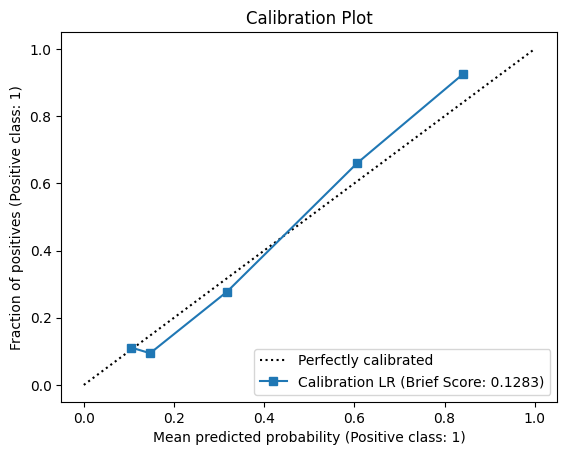

In [46]:
# calculate calibaration curve using probabilities and brier score for logistic regression 
from sklearn.metrics import brier_score_loss
from sklearn.calibration import CalibratedClassifierCV

# Apply platt scaling
calibrated_lr = CalibratedClassifierCV(estimator= lr, method = 'sigmoid', cv = 5, n_jobs = -1)

# train model on data 
calibrated_lr.fit(X_train1, Y_train1)

# get probabilties 
calibrated_lr_probs = calibrated_lr.predict_proba(X_test1)[:,1]

# calculate brier score
lr_brier = brier_score_loss(Y_test1, calibrated_lr_probs)

# plot the display
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt 
CalibrationDisplay.from_estimator(calibrated_lr,  X_test1, Y_test1, n_bins= 5, strategy= 'quantile', name = f'Calibration LR (Brief Score: {lr_brier:.4f})')
plt.title('Calibration Plot')
plt.show()

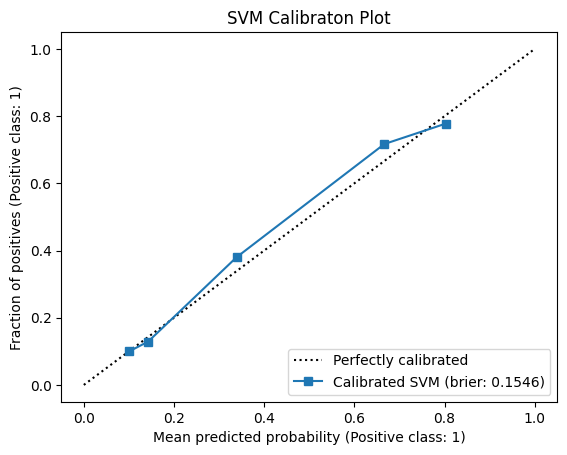

In [38]:
# calculate the calibration curve for SVM model 
from sklearn.calibration import CalibratedClassifierCV

# calculate calibration curve 
calibrated_svc = CalibratedClassifierCV(svm, method = 'isotonic', cv = 5)

# fit data on model 
calibrated_svc.fit(X_train2, Y_train2)

#calculate probabilites
calibrated_svm_probs = calibrated_svc.predict_proba(X_test2)[:,1]

# breir score
from sklearn.metrics import brier_score_loss
brier = brier_score_loss(Y_test2, svm_probs)

# plot the display 
from sklearn.calibration import CalibrationDisplay
disp = CalibrationDisplay.from_estimator(calibrated_svc, X_test2, Y_test2, n_bins = 5, name = f'Calibrated SVM (brier: {brier:.4f})', strategy='quantile' )
# add basline for "Perfect Calibration"
plt.title('SVM Calibraton Plot')
plt.show()


# Roc-Auc and Pr-Auc Curve 


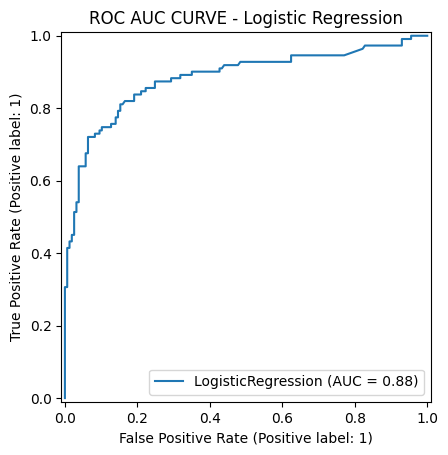

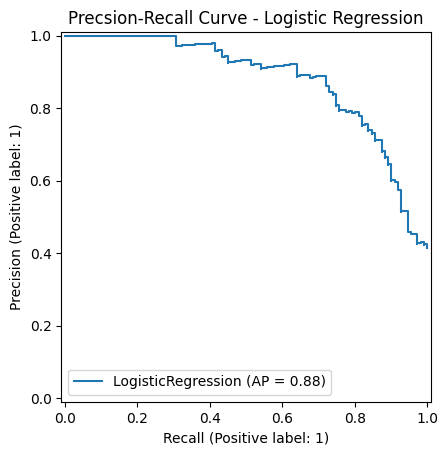

In [55]:
# plot curve 
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay 

# Roc Auc (comparing true false positive rates against the false positive rate at different thresholds)
RocCurveDisplay.from_estimator(lr, X_test1, Y_test1)
plt.title('ROC AUC CURVE - Logistic Regression')
plt.show()

# Precision Recall Curve (Compares precision and recall at different thresholds)
PrecisionRecallDisplay.from_estimator(lr, X_test1, Y_test1)
plt.title('Precsion-Recall Curve - Logistic Regression')
plt.show()


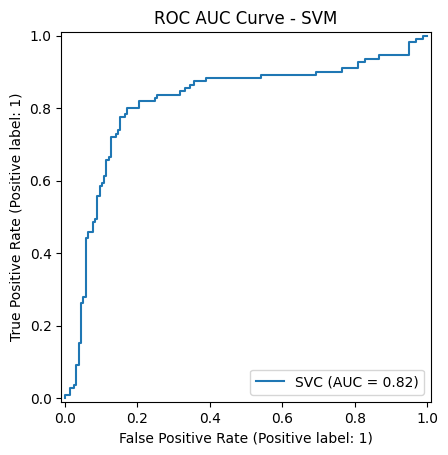

[]

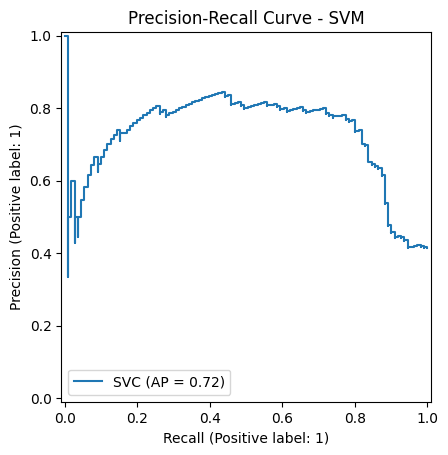

In [58]:
# plot curve for SVM 
RocCurveDisplay.from_estimator(svm, X_test2, Y_test2)
plt.title('ROC AUC Curve - SVM')
plt.show()

PrecisionRecallDisplay.from_estimator(svm, X_test2, Y_test2)
plt.title('Precision-Recall Curve - SVM')
plt.plot()

# Model Winner
- Logistic Regression is the winner and performs very well with a brier score of 0.126. The line also hugs the diagnoal line very closely, signaling a confidence in probabilites. The SVM line weaves alot more and is underconfident in the middle and overconfident on the high end. 